### Load the saved result

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(
    r"C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML"
)

RESULT_FILE = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "thermal_anomaly_prototype.csv"
)

data = pd.read_csv(RESULT_FILE)

print("Shape:", data.shape)
print("Loaded successfully.")

data.head()

Shape: (439251, 25)
Loaded successfully.


,acq_date,start_time,end_time,latitude,longitude,observation_count,duration_minutes,mean_frp,peak_frp,total_frp,...,day_of_week,month,is_weekend,persistent,long_duration,is_day,is_night,anomaly_score,anomaly_prediction,is_anomaly
0,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,8.984920,77.60124,1,0.0,8.350,8.35,8.35,...,2,1,0,0,0,1,0,0.093408,1,0
1,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,9.000140,77.61005,1,0.0,2.680,2.68,2.68,...,2,1,0,0,0,1,0,0.106868,1,0
2,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,9.278090,78.04165,1,0.0,1.580,1.58,1.58,...,2,1,0,0,0,1,0,0.096588,1,0
3,2025-01-01,2025-01-01 19:49:00,2025-01-01 19:49:00,9.562105,77.63444,2,0.0,1.105,1.23,2.21,...,2,1,0,1,0,0,1,0.005439,1,0
4,2025-01-01,2025-01-01 07:38:00,2025-01-01 07:38:00,9.630170,76.47209,1,0.0,2.110,2.11,2.11,...,2,1,0,0,0,1,0,0.108285,1,0


anomaly summary

In [2]:
total_events = len(data)

normal_events = (data["is_anomaly"] == 0).sum()
anomalous_events = (data["is_anomaly"] == 1).sum()

anomaly_percentage = (
    anomalous_events / total_events
) * 100

print("Total events:", total_events)
print("Normal events:", normal_events)
print("Anomalous events:", anomalous_events)
print(f"Anomaly percentage: {anomaly_percentage:.2f}%")

Total events: 439251
Normal events: 356761
Anomalous events: 82490
Anomaly percentage: 18.78%


### Anomaly score distribution

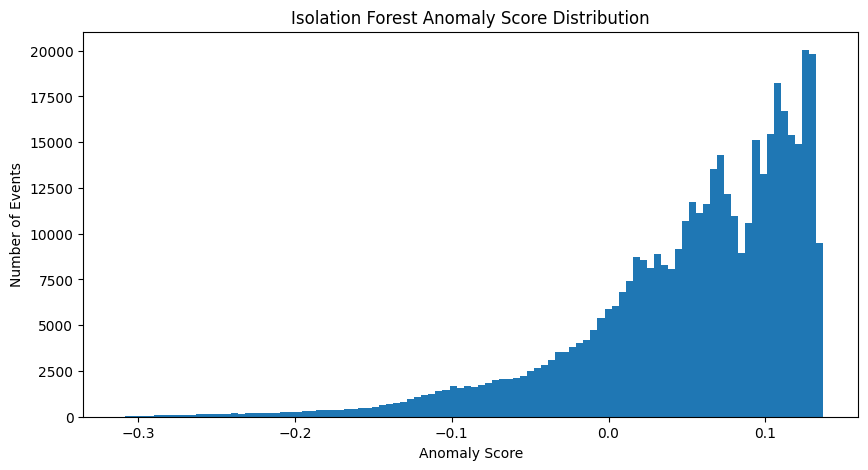

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    data["anomaly_score"],
    bins=100
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Events")
plt.title("Isolation Forest Anomaly Score Distribution")

plt.show()

### Top 20 most unusual events

In [4]:
top_20 = (
    data
    .sort_values("anomaly_score", ascending=True)
    .head(20)
)

columns_to_show = [
    "acq_date",
    "start_time",
    "latitude",
    "longitude",
    "observation_count",
    "duration_minutes",
    "mean_frp",
    "peak_frp",
    "total_frp",
    "anomaly_score"
]

top_20[columns_to_show]

,acq_date,start_time,latitude,longitude,observation_count,duration_minutes,mean_frp,peak_frp,total_frp,anomaly_score
328968,2025-03-11,2025-03-11 07:22:00,23.347989,93.156427,7,52.0,354.950000,1775.10,2484.65,-0.312441
316829,2025-03-10,2025-03-10 06:01:00,23.824853,93.004640,11,48.0,177.248182,821.09,1949.73,-0.309150
298674,2025-03-08,2025-03-08 06:37:00,23.744789,93.425108,12,49.0,200.855000,589.82,2410.26,-0.309150
298688,2025-03-08,2025-03-08 06:37:00,23.751950,93.424815,13,78.0,195.993846,502.13,2547.92,-0.308329
298276,2025-03-08,2025-03-08 06:37:00,23.373449,93.174498,14,78.0,119.783571,396.66,1676.97,-0.307782
61811,2025-01-24,2025-01-24 06:46:00,27.535576,91.795841,10,48.0,162.681000,677.72,1626.81,-0.307236
385791,2025-03-15,2025-03-15 06:08:00,23.942491,93.325114,10,47.0,128.282000,545.43,1282.82,-0.306690
316297,2025-03-10,2025-03-10 05:59:00,23.456601,92.766070,7,49.0,311.712857,934.02,2181.99,-0.306360
368612,2025-03-14,2025-03-14 06:27:00,22.735075,92.984745,11,46.0,113.886364,565.24,1252.75,-0.305871
284962,2025-03-07,2025-03-07 06:58:00,23.212340,92.883678,8,47.0,154.268750,674.01,1234.15,-0.305599


### Compare normal vs anomalous

In [5]:
comparison = (
    data.groupby("is_anomaly")[
        [
            "observation_count",
            "duration_minutes",
            "mean_frp",
            "peak_frp",
            "total_frp"
        ]
    ]
    .mean()
)

comparison.index = ["Normal", "Anomalous"]

comparison

,observation_count,duration_minutes,mean_frp,peak_frp,total_frp
Normal,1.251785,2.622173,4.704100,4.905263,5.983673
Anomalous,3.108013,21.643666,16.476572,23.370274,46.758252


### Spatial visualization

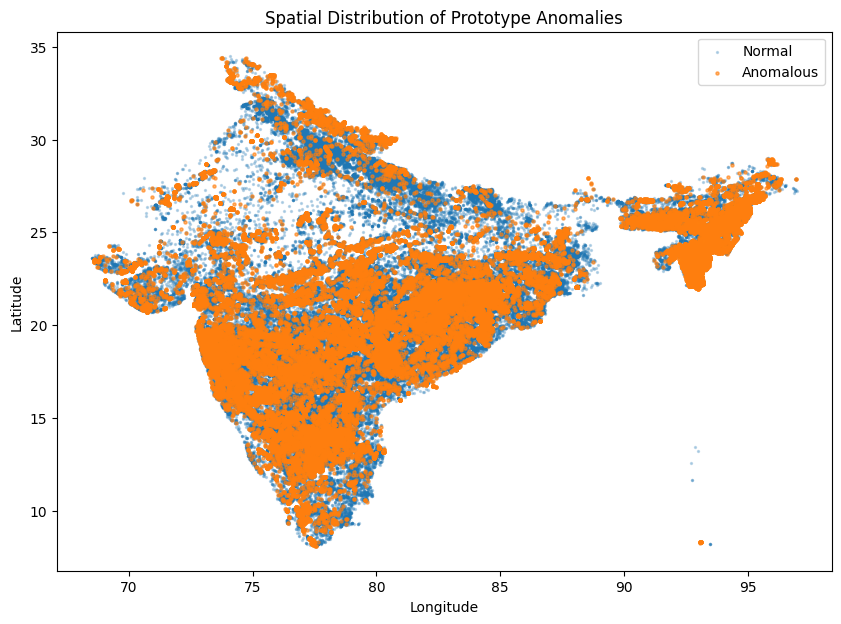

In [6]:
plt.figure(figsize=(10, 7))

normal = data[data["is_anomaly"] == 0]
anomalous = data[data["is_anomaly"] == 1]

plt.scatter(
    normal["longitude"],
    normal["latitude"],
    s=2,
    alpha=0.25,
    label="Normal"
)

plt.scatter(
    anomalous["longitude"],
    anomalous["latitude"],
    s=5,
    alpha=0.6,
    label="Anomalous"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Prototype Anomalies")
plt.legend()

plt.show()

### Save an evaluation summary

In [7]:
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

evaluation_summary = {
    "total_events": int(total_events),
    "normal_events": int(normal_events),
    "anomalous_events": int(anomalous_events),
    "anomaly_percentage": float(anomaly_percentage)
}

import json

REPORT_FILE = REPORT_DIR / "prototype_anomaly_evaluation.json"

with open(REPORT_FILE, "w") as f:
    json.dump(evaluation_summary, f, indent=4)

print("Evaluation report saved:")
print(REPORT_FILE)

Evaluation report saved:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\reports\prototype_anomaly_evaluation.json
